# Name: Christian Lambert

Add anything else for indentification/or however you want to label this notebook up here before submitting. 

# Submission
You do not need to write up a separate report since there will be space for you to write down thoughts/answer questions throughout this notebook. Instead, when you are finished, go to File --> Save and Export Notebook As --> LaTeX (or as pdf, but this option hasn't been working). This will convert the notebook to a .tex file which can be uploaded into Overleaf and compiled into an already formatted pdf. 

# Introduction
This homework goes over the concepts of calculating $\chi^{2}$ and reduced $\chi^{2}$ to see the goodness of fit of a model to provided data. We then implement an offshoot of this through Markov Chain Monte Carlo (MCMC) Simulations, which use a maximum log-likelihood to judge goodness of fit. It is important to note that maximizing log-likelihood is the same as minimizing chi-squared.

Please watch the following videos, then start filling in the below notebook cells to complete the problems.

Required videos to watch:
1. An introduction to $\chi^{2}$ and reduced $\chi^{2}$: https://www.youtube.com/watch?v=KNLhep3UZ68
2. An introduction to the background of MCMC Simulations: https://www.youtube.com/watch?v=nndtTssgtZE

Optional supplemental materials to read for $\chi^{2}$ and MCMC:
1. https://events.mpifr-bonn.mpg.de/indico/event/30/material/slides/12.pdf - Read sections 2.3-2.4 and 3
2. https://prappleizer.github.io/Tutorials/MCMC/MCMC_Tutorial_Solution.html - Implementation of MCMC

Chi Squared
-
Equation for it:
$$\chi^{2} = \sum_{i=1}^{N}{\frac{(y_{i}^{OBS}-y_{i}^{MOD})^{2}}{\epsilon_{y_{i}}^{2}}}$$
where $y_{i}^{OBS}$ are the data/observations with error estimation $\epsilon_{y_{i}}$, and $y_{i}^{MOD}$ is the model function.

Reduced Chi-Squared
-
Another important value is the number of degrees of freedom in the model, $\nu$, defined as 
$$\nu = n - p$$
where $n$ is the number of datapoints (measurements) and $p$ are the number of fitted parameters. 

With this, we can determine how well the model has fit the data by using the reduced $\chi^{2}_{\nu}$ which is defined as the chi-square per degree of freedom:

$$\chi^{2}_{\nu} = \frac{\chi^{2}}{\nu}$$

To determine how well the model has fit the data, we use the reduced $\chi^{2}_{\nu}$:
- $\chi^{2}_{\nu} < 1 \rightarrow$ over-fitting of the data
- $\chi^{2}_{\nu} > 1 \rightarrow$ poor model fit
- $\chi^{2}_{\nu} \simeq 1 \rightarrow$ good match between data and model in accordance with the data error

Taken from: https://events.mpifr-bonn.mpg.de/indico/event/30/material/slides/12.pdf (Section 2.3)

In [602]:
#Import necessary packages
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

## Simple power law [0.5 pts]

To get started, run the cell below. It's some fake noisy data that forms a power law to help ensure that your code is working. Feel free to change the parameters. The model for this problem is the power law which takes the functional form
$$y = Ax^{k}$$
where $A$ is a constant and $k$ is the exponent (or power law index). 

The goal is to explore how $\chi^{2}$ explores the parameter space for two parameters (A and k) by making a brute force $\chi^{2}$ algorithm. 

In [603]:
np.random.seed(42) #just so I get the same values as I repeat the procedure as a check to make sure things work

#power law params
A = 5.35        
k = -1.74 
x = np.linspace(1, 100, 100) #range of x values 
y_true = A*x**k #eqn without noise

noise = np.random.normal(0, 0.2 * y_true) #noise 

y = y_true + noise #the equation I want the model to fit to
y_err = 0.2*y_true #just some errors - they are Gaussian!

The first thing to do is make some functions for the model, $\chi^{2}$, and $\chi^{2}_{\nu}$.

In [604]:
# Define functions

def chi_sq(data, model, error):
    return np.sum((data - model)**2 / error**2)


def red_chi_sq(data, model, error, dof):
    return chi_sq(data, model, error) / dof

### Two Parameter Fit [2 pts]
Start with the two parameter fit in which for each combination of $A$ and $k$, a $\chi^{2}$ and $\chi^{2}_{\nu}$ is computed. Print out some of these values for a few of the iterations to see how they change. What do you notice? Hint: Define a grid of values for $\chi^{2}$ to search through. 


Note: This is a brute force method that explores the whole defined parameter space. It does not try to get the lowest-chi squre value.

In [605]:
# Two param fit
def two_param(k, A, x):
    return A*x**k

A_arr = np.linspace(0,10,101)
k_arr = np.linspace(-5,5,101)

chi_arr = np.zeros([len(A_arr), len(k_arr)])

for A in range(len(A_arr)):
    row = np.zeros(len(k_arr))
    for k in range(len(k_arr)):
        model = two_param(k_arr[k], A_arr[A], x)
        row[k] = chi_sq(y, model, y_err)
    
    chi_arr[A] = row

print(chi_arr)

[[2.47888411e+03 2.47888411e+03 2.47888411e+03 ... 2.47888411e+03
  2.47888411e+03 2.47888411e+03]
 [2.47771432e+03 2.47769917e+03 2.47768218e+03 ... 9.61165091e+24
  2.38284529e+25 5.90852065e+25]
 [2.47656219e+03 2.47653194e+03 2.47649799e+03 ... 3.84466036e+25
  9.53138116e+25 2.36340826e+26]
 ...
 [2.44825549e+03 2.44692647e+03 2.44544116e+03 ... 9.23102953e+28
  2.28848462e+29 5.67454323e+29]
 [2.44881789e+03 2.44747692e+03 2.44597833e+03 ... 9.42037906e+28
  2.33542667e+29 5.79094109e+29]
 [2.44939797e+03 2.44804508e+03 2.44653325e+03 ... 9.61165091e+28
  2.38284529e+29 5.90852065e+29]]


Comments: I notice very large variation in chi values as a function of k, less so for A

Now, find and report the lowest value of $\chi^{2}_{\nu}$ and the corresponding $\chi^{2}$, $A$, and $k$. These are your best fit parameters. 

In [606]:
# Get the best values - The printed output is fine

A_ind, k_ind = np.where(chi_arr == np.min(chi_arr))
A_fit = A_arr[A_ind]
k_fit = k_arr[k_ind]

dof = len(x)-2

print(f'The minimum reduced chi-squared value is {np.min(chi_arr)/dof} at A = {A_fit} and k = {k_fit}.')
print(f'The minimum chi-squared value is {np.min(chi_arr)}.')

The minimum reduced chi-squared value is 0.8750398961051705 at A = [4.5] and k = [-1.7].
The minimum chi-squared value is 85.75390981830671.


Plot the data, model with the best-fit parameters, and residuals in log-log space (You should see a line). Comment on the fit.

Text(0.5, 1.0, 'Two-Parameter Fit')

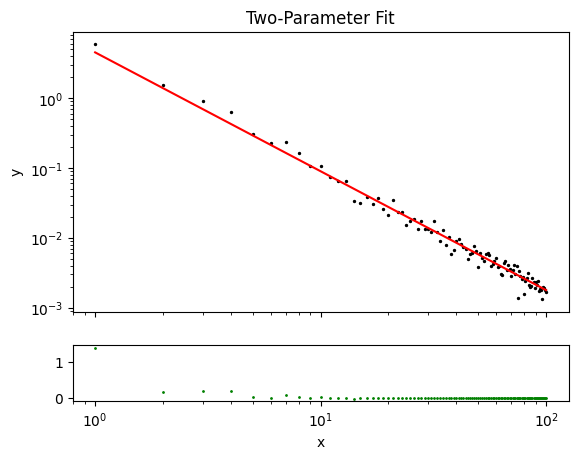

In [607]:
# Plot in loglog - You should see a line

y_model = A_fit * x ** k_fit

fig, (ax1, ax2) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [5, 1]}, sharex=True)

data = ax1.scatter(x, y, color='black', s=2)
model = ax1.plot(x, y_model, color='red')
res = ax2.scatter(x, y - y_model, color='green', s=1)

ax1.set_xscale('log')
ax1.set_yscale('log')
ax2.set_xlabel('x')
ax1.set_ylabel('y')

ax1.set_title('Two-Parameter Fit')

Comments: the fit looks good, reduced chi2 is lower than 1 but is statistically ok

We can also see how how $\chi^{2}$ changes as it cycles through the different combinations of parameters. To do this, make a contour plot of $A$ vs $k$ with a colorbar indicating $\chi^{2}$. Include a point indicating your best fit parameters. Comment on the parameter space in relation to thest best-fit values.

Hint: Use LogNorm for the colorbar. The plot should look choppy if you have a low grid resolution, which is fine. If you want, you can make a finer grid, but that will very quickly make the $\chi^{2}$ search become more computationally expensive. 

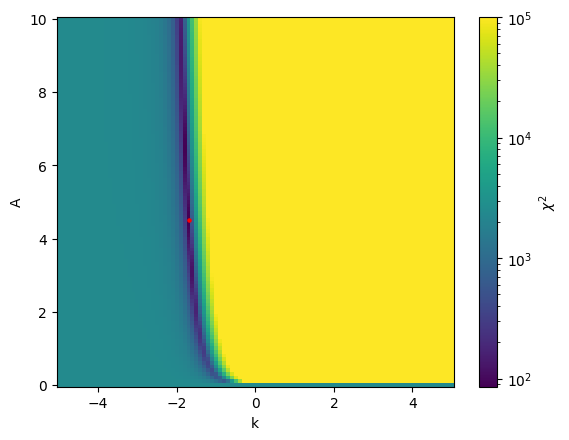

In [608]:
# Contour plot
import matplotlib.colors as colors

X, Y = np.meshgrid(k_arr, A_arr)

plt.pcolormesh(X, Y, chi_arr, shading='auto', norm=colors.LogNorm(vmax=1e5))
plt.colorbar(label=r'$\chi^2$')

plt.xlabel('k')
plt.ylabel('A')

plt.scatter(k_fit, A_fit, color='red', s=5)

Comments: can lower vmax to see the tiny area around the point with low chi, but this shows the strong trend with k

## Real Data [2 pts]
Now let's apply what we've done from before to some real data. Download Stellar_Data.txt which holds mass ($M_{\odot}$), log stellar age (log years), log accretion rate (log $M_{\odot}/yr$), and log accretion rate errors. Note: The data is already in log scale, so how will that change your model function?

In [609]:
# Load in the data
data = np.loadtxt('HW07_Stellar_Data.txt', skiprows=1)

In [610]:
# New model function here
def new_mod(k, A, age):
    return A + k * age

Use the brute force method for two parameters from before. Play around with your parameter space and print out some parameters with their $\chi^{2}$, and $\chi^{2}_{\nu}$. Comment on what you notice about these values.

In [611]:
# Brute force method

mass = data[:,0]
age = data[:,1]
macc = data[:,2]
macc_err = data[:,3]

sort_ind = np.argsort(age)
mass = mass[sort_ind]
age = age[sort_ind]
macc = macc[sort_ind]
macc_err = macc_err[sort_ind]

A_arr = np.linspace(-10, 0, len(macc))
k_arr = np.linspace(-2, 1, len(macc))

chi_arr = np.zeros([len(A_arr), len(k_arr)])

for A in range(len(A_arr)):
    row = np.zeros(len(k_arr))
    for k in range(len(k_arr)):
        model = new_mod(k_arr[k], A_arr[A], age)
        row[k] = chi_sq(macc, model, macc_err)
    
    chi_arr[A] = row

print(chi_arr[0][:5])
print(chi_arr[0][:5]/(len(age)-2))

[5391371.43579316 5331096.39876144 5271160.73417217 5211564.44202535
 5152307.52232098]
[23238.66998187 22978.86378776 22720.52040591 22463.63983632
 22208.22207897]


Comments: I notice very large and widely varying values

Now, find and report the lowest value of $\chi^{2}_{\nu}$ and the corresponding parameters and $\chi^{2}$. These are your best fit parameters.

In [612]:
# Best-fit params
A_ind, k_ind = np.where(chi_arr == np.min(chi_arr))
A_fit = A_arr[A_ind]
k_fit = k_arr[k_ind]

print(f'The minimum reduced chi-squared value is {np.min(chi_arr)/(len(macc)-2)} at A = {A_fit} and k = {k_fit}.')
print(f'The minimum chi-squared value is {np.min(chi_arr)}.')

The minimum reduced chi-squared value is 17.52876096725294 at A = [-5.87982833] and k = [-0.33905579].
The minimum chi-squared value is 4066.672544402682.


As before, plot the data with errors, model with the best-fit parameters, and residuals in log-log space. Make sure to include units on the plot. Comment on the fit. Look back at $\chi^{2}_{\nu}$ value you got, what does this value mean for your model? How could one improve $\chi^{2}_{\nu}$? 

Text(0.5, 1.0, 'Two-Parameter Fit')

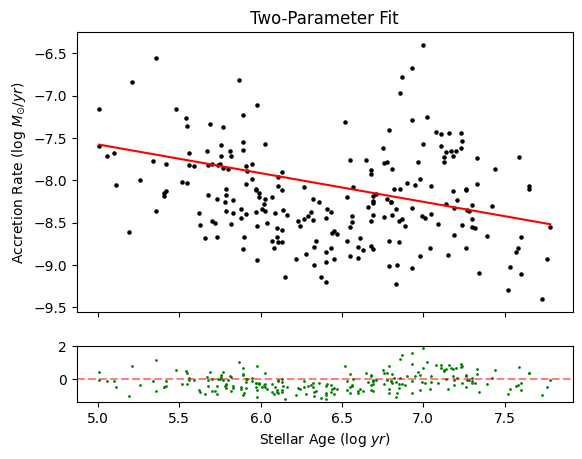

In [613]:
# Plot it up

macc_model = A_fit + k_fit * age

fig, (ax1, ax2) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [5, 1]}, sharex=True)

data = ax1.scatter(age, macc, color='black', s= 5)
model = ax1.plot(age, macc_model, color='red')
res = ax2.scatter(age, macc - macc_model, color='green', s=1)
ax2.axhline(0, color='red', alpha=0.5, linestyle='--')

ax2.set_xlabel(r'Stellar Age (log $yr$)')
ax1.set_ylabel(r'Accretion Rate (log $M_{\odot}/yr$)')

ax1.set_title('Two-Parameter Fit')

Comments: The fit looks reasonable, although im suspicious of the gap in the data in the middle... almost looks like a quadratic would fit better

Answers: Our reduced chi-squared value is above 1, which suggests our fit isn't optimal. We could try a more complex model or increase grid resolution to better fit our data.

Also, make the contour plot of parameter 1 vs parameter 2 with a colorbar indicating $\chi^{2}$ again. Add the point indicating your best-fit parameters. Comment on the parameter space in relation to these best-fit values. 

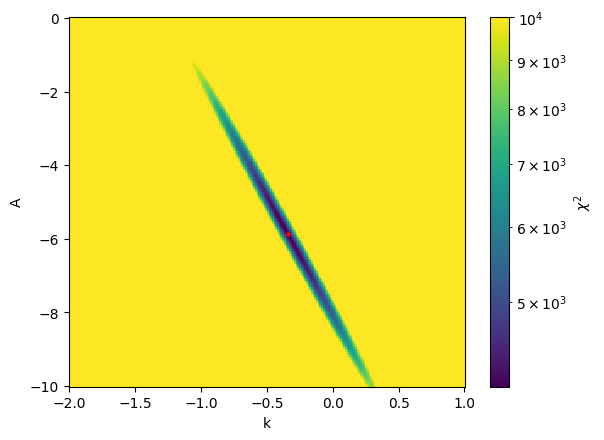

In [614]:
# Contour plot

X_grid, Y_grid = np.meshgrid(k_arr, A_arr)

plt.pcolormesh(X_grid, Y_grid, chi_arr, shading='auto', norm=colors.LogNorm(vmax=1e4))
plt.colorbar(label=r'$\chi^2$')

plt.xlabel('k')
plt.ylabel('A')

plt.scatter(k_fit, A_fit, color='red', s=5)

Comments: The parameter space closes on our value with a largely eccentric range of values

# Fitting Stellar Accretion [5.5 pts]

In this part we are going to be using the the emcee package to run MCMC on a data set for stellar accretion
https://emcee.readthedocs.io/en/stable/

We will work through the steps in https://prappleizer.github.io/Tutorials/MCMC/MCMC_Tutorial_Solution.html to set up the MCMC.

In [615]:
pip install emcee

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [616]:
import emcee

First, load Stellar_Data.txt into the notebook and make a scatter plot of logAge vs logMacc. Note: the data is already logarithmic. [0.5 pts]

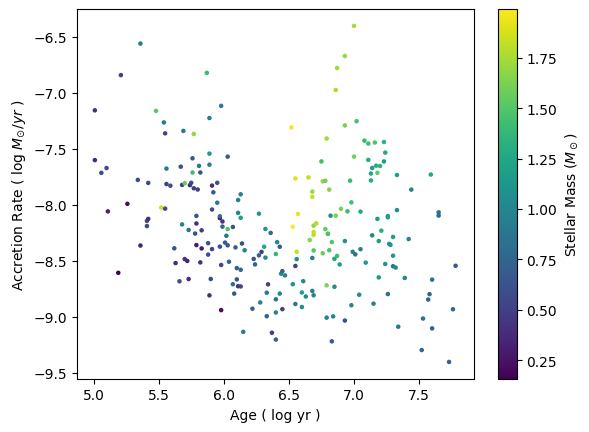

In [617]:
# Load data and plot

# already did this^

plt.scatter(age, macc, c=mass, s=5)
plt.xlabel('Age ( log yr )')
plt.ylabel(r'Accretion Rate ( log $M_{\odot}/yr$ )')
plt.colorbar(label=r'Stellar Mass ($M_\odot$)')

Create the linear model definition, the log likelihood definition, the lnprior definition, and the posterior probability definition. [1 pnt]

In [618]:
# Linear Model Def

def lin_model(theta, x):
    b, m = theta
    return b + m * x 

# Log Likelihood Def

def lnlike(theta, x, y, yerr):
    return -0.5 * np.sum(((y - lin_model(theta, x))/yerr) ** 2)

# lnprior Def

def lnprior(theta):
    b, m = theta
    if -2 < m < 2 and -10 < b < 10:
        return 0.0
    return -np.inf

# Posterior Prob Def

def lnprob(theta, x, y, yerr):
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike(theta, x, y, yerr)

Use the definitions to run the emcee. Your number of walkers should be some power of 2, and your number of iterations should be some value over 100. [1 pts]

In [619]:
# Parameters
args = (age, macc, macc_err)
nwalk = 128
niter = 500
initial = np.array([-10,-1])
ndim = len(initial)
p0 = [np.array(initial) + 1e-7 * np.random.randn(ndim) for i in range(nwalk)]

# Run MCMC

sampler = emcee.EnsembleSampler(nwalk, ndim, lnprob, args=args)
pos, prob, state = sampler.run_mcmc(p0, niter)


/Users/christian.h.lambert-1/Library/Python/3.14/lib/python/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


Make a plot of the parameters' values over each step (typically referred to as a convergence or trace study). Comment on the value of the parameters as the MCMC runs. Hint: This information is encoded in the get_chain() function. [1 pnt]

Text(0.5, 0, 'n_iter')

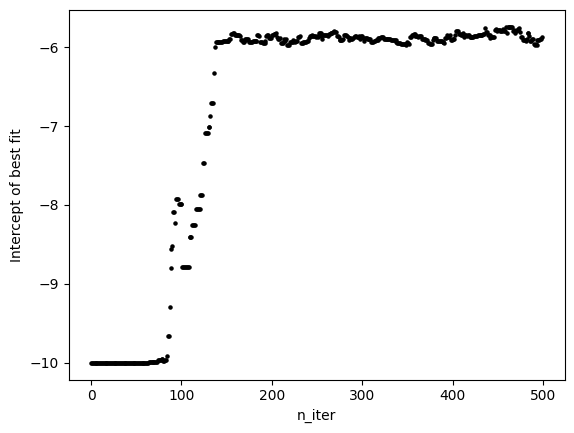

In [620]:
# Plot parameter values versus steps (iterations)
plt.scatter(np.arange(niter), sampler.get_chain()[:,0][:,0], color='black', s=5)

plt.ylabel('Intercept of best fit')
plt.xlabel('n_iter')

Text(0.5, 0, 'n_iter')

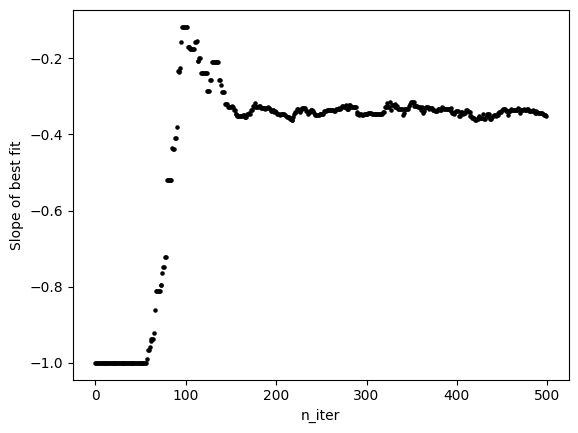

In [621]:
# Plot parameter values versus steps (iterations)
plt.scatter(np.arange(niter), sampler.get_chain()[:,1][:,1], color='black', s=5)

plt.ylabel('Slope of best fit')
plt.xlabel('n_iter')

After running emcee, plot the original data with the best fit line calculated from the emcee. Comment on the plot. [1 pnt]

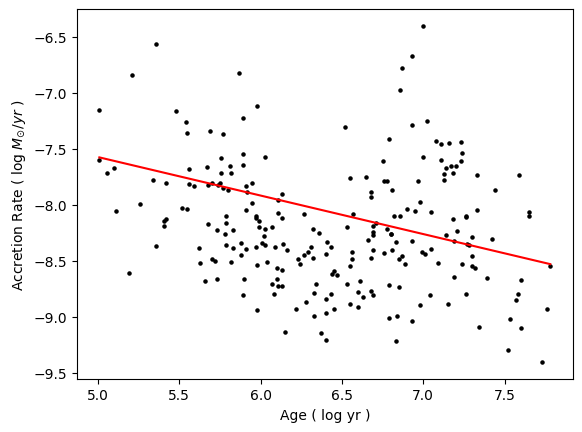

In [622]:
# Plot data and best-fit line
samples = sampler.flatchain
int_fit, slope_fit = samples[np.argmax(sampler.flatlnprobability)]

model = np.array(int_fit + slope_fit * age)

plt.scatter(age, macc, color='black', s=5)
plt.xlabel('Age ( log yr )')
plt.ylabel(r'Accretion Rate ( log $M_{\odot}/yr$ )')

plt.plot(age, model, color='red')


Comments: It looks reasonable for a linear estimate in log-space

Finally, use the original data, its errors, and the emcee model data to calculate $\chi^{2}$ and $\chi^{2}_{v}$. Comment on the results. [1 pnt]

In [623]:
# Calculate chi-squared

chi2 = chi_sq(macc, model, macc_err)

# Calculate reduced chi-squared

red_chi2 = red_chi_sq(macc, model, macc_err, len(macc)-2)

print(f'The chi-squared and reduced chi-squared values are {chi2} and {red_chi2}, resepectively.')

The chi-squared and reduced chi-squared values are 4065.660468311553 and 17.524398570308417, resepectively.


Comments: Again we have a reduced chi-square value above 1, suggesting our linear (power-law) fit is not very good.